# 01 · 루프: 스케줄링과 완료까지 반복

**구성요소:** 자동화 / 스케줄링과 완료까지 반복(run-until-done)

**핵심 아이디어**

> "심박이다. 스케줄링이 없으면 남는 것은 일회성 에이전트 실행뿐이다."

> 완료까지 반복이란 — **"검증 가능한 조건이 성립할 때까지 계속 일한다."**

**문제 설정** — **MBPP+**(EvalPlus)의 파이썬 함수를 작성한다. 주어지는 것은 자연어 설명과 요구되는 함수 이름뿐이다. 의미 있는 비율이 첫 시도에서 실패한다. 테스트를 돌리고 실패한 케이스를 되먹이는 루프라면 그중 상당수를 고쳐야 한다. **단, 그 피드백이 진짜일 때만 그렇다.**

**측정 대상** — 시도 1회의 pass@1 대비, N회 반복 안에 풀린 비율. 실행 피드백이 있을 때와 없을 때 각각. 여기에 루프의 비용과, 시도 상한이 존재하는 이유인 "무한 수정 루프" 실패 양식을 더한다.

**연구 배경** — Self-Refine(Madaan et al., 2303.17651)과 Reflexion 은 피드백 신호가 있을 때 반복적 자기 개선이 도움이 된다는 것을 보였다. Huang et al. (2023)은 LLM 이 **외부 피드백 없이는** 신뢰할 만하게 자기 교정을 하지 못한다는 것을 보였다. 이 노트북은 그 양쪽을 실제 코드에서 재현한다.

**정직한 범위 설정 (이 기계에서 직접 확인함)** — 처음에는 이 루프를 어려운 LiveCodeBench 문제에 돌렸고 **개선이 0 이었다.** 거기서 모델의 실패는 *알고리즘적*이다. 접근법 자체가 틀렸다. 그런 상황에서 "3을 기대했는데 4가 나왔다" 같은 실행 피드백은 유효하지만 여전히 틀린 수정을 만들어 낸다. **올바른 알고리즘이 무엇인지 알려 주지 않기 때문이다.** 루프가 자기 몫을 하는 것은 실패가 *얕고 고칠 수 있을 때*다 — 하나 차이(off-by-one), 경계 케이스, 잘못된 파싱. MBPP+ 가 보여 주는 것이 그 종류다. 그래서 이 구성요소를 그것이 실제로 적용되는 자리에서 시연하고, 그 한계를 그대로 진술한다.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  실행 환경 (자동 판별)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LLM       : openai    gpt-5.6-luna
              ↳ localhost 무응답 → OPENAI_API_KEY 감지 · 선호 순위표에서 자동 선택 (캐시)
  임베딩    : openai    text-embedding-3-small
              ↳ CUDA 미가용 → API 임베딩 · 기본값 (캐시)
  데이터    : /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/data
  전환      : LLM_PROVIDER=vllm|openai  /  EMBED_PROVIDER=local|openai
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

============================================== Setup ===============================================

-------------------------------------------- 엔진 health ---------------------------------------------
{
  "provider": "openai",
  "model": "gpt-5.6-luna",
  "base_url": "(\uacf5\uc2dd \uc5d4\ub4dc\ud3ec\uc778\ud2b8)",
  "reply": "ready",
  "deterministic": true,
  "cost_usd": "$0.0000",
  "resolved_by": "localho

*완료까지 반복하는 루프: 생성 → 테스트 실행 → 실패 되먹임 → 수정 → 상한까지 반복*

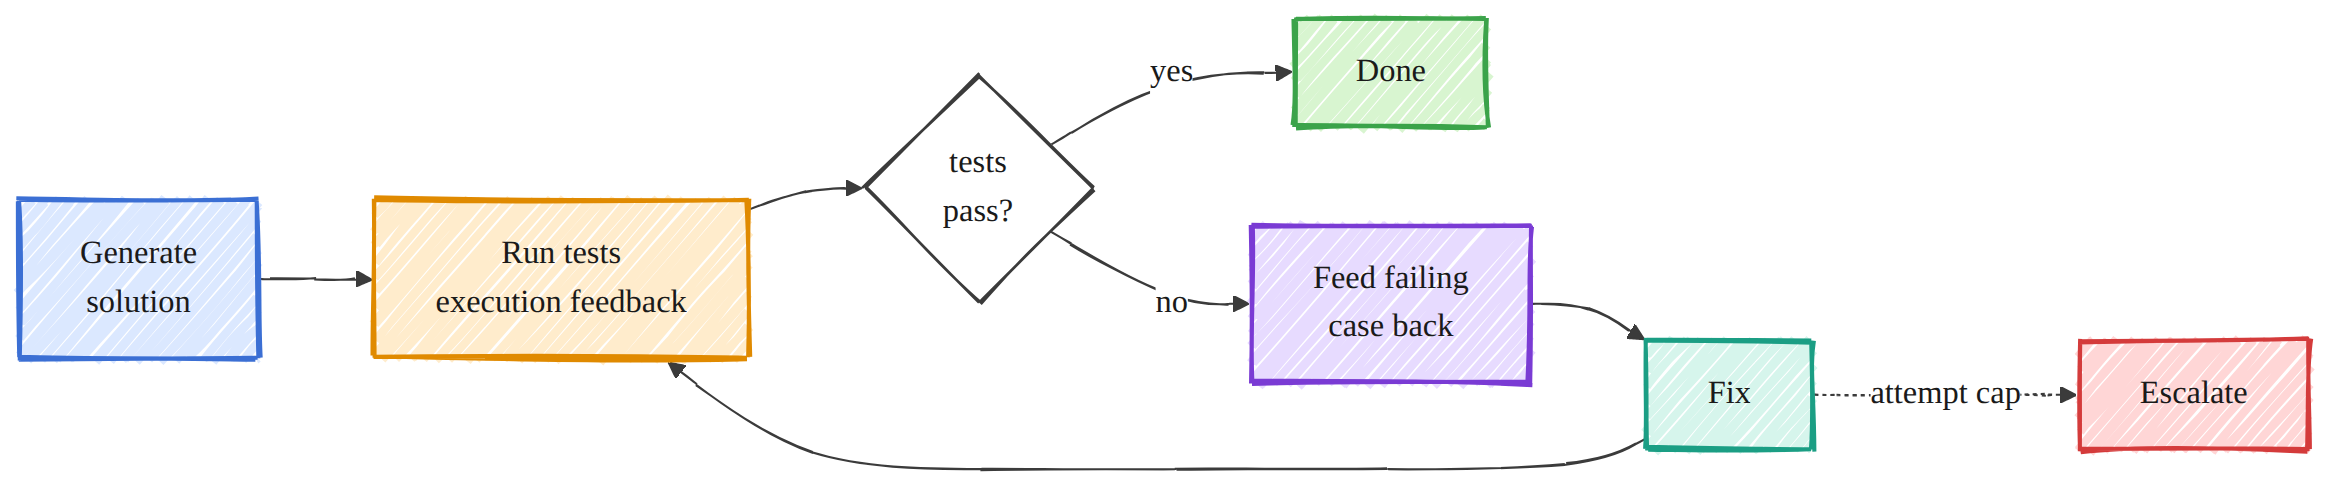

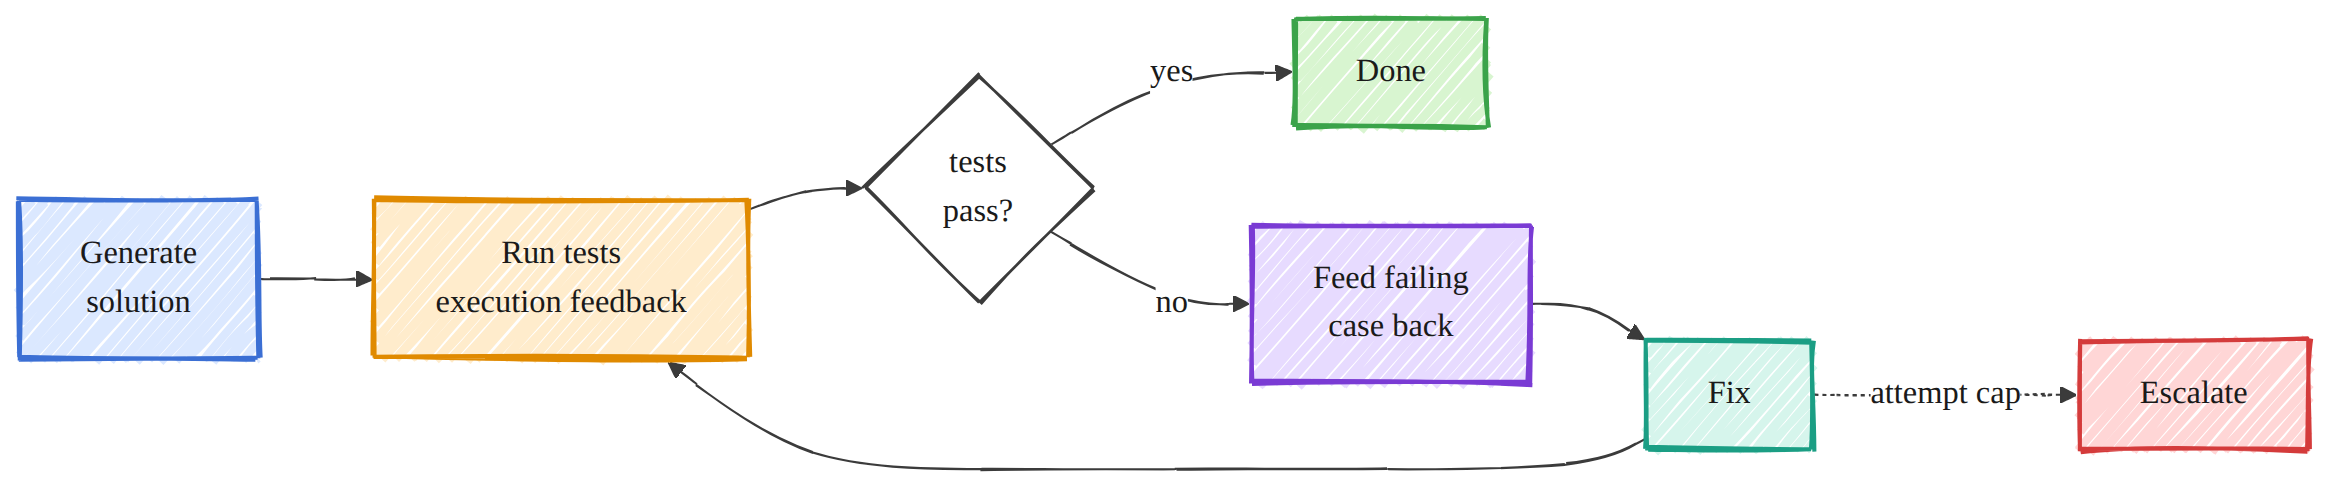

In [1]:
import os
import sys
import time

sys.path.insert(0, os.environ.get("LEN_PROJECT_ROOT", os.path.abspath(".")))

from common import show, data, agents, loops, plotting, runlog, runtime
from common.llm import LLM

# ── 실험 상수 ─────────────────────────────────────────────────────
# 60문제: 통계적으로 의미가 있으면서 A100 한 장에서 세 조건(베이스라인 /
#         피드백 있음 / 피드백 없음)을 모두 돌릴 수 있는 크기다.
# 3회 상한: 업계에서 흔히 쓰는 기본값이고, 20번 셀에서 이 상한이 왜
#         선택 사항이 아닌지를 직접 보여 준다.
N_PROBLEMS = 60
MAX_ATTEMPTS = 3

# 실행 환경 자동 판별 (로컬 vLLM 우선, 없으면 OpenAI API)
rt = runtime.bootstrap()

llm = LLM()
show.head("Setup")
show.show_dict(llm.health(), "엔진 health")

# seed=0 으로 고정한다. 문제 표본이 실행마다 바뀌면 세 조건을 비교할 수 없다.
problems = data.load_mbpp_plus(limit=N_PROBLEMS, seed=0)
show.kv("불러온 문제 수", len(problems))
show.diagram("loop_iter", "완료까지 반복하는 루프: 생성 → 테스트 실행 → 실패 되먹임 → 수정 → 상한까지 반복")

### 첫 시도 실패 사례 하나와, 루프가 사용할 피드백

앞쪽 몇 문제를 훑어 모델이 탐욕적 시도 한 번으로 틀리는 것을 하나 찾고, **루프의 피드백이 될 실제 assertion 오류**를 보여 준다.


In [2]:
# ── 첫 시도 실패 사례 하나를 찾는다 ────────────────────────────────
p0 = None
code0 = None
for p in problems[:12]:
    c, _ = agents.single_shot(llm, p, temperature=0.0, label="walk")
    # all_pass 가 False 인 첫 문제에서 멈춘다. 루프가 다룰 대상의 실물이다.
    if not agents.grade(p, c)["all_pass"]:
        p0, code0 = p, c
        break

if p0 is None:
    # 12문제가 전부 통과했다면 시연할 실패가 없다. 그래도 흐름은 보여 준다.
    p0 = problems[0]
    code0, _ = agents.single_shot(
        llm, 
        p0, 
        temperature=0.0, 
        label="walk"
    )
    show.bullet("앞 12문제가 모두 1회차에 통과했다. 그래도 첫 문제를 그대로 보여 준다.")

show.sub(p0.id)
show.text(p0.prompt, "문제", max_chars=500)
show.text(p0.tests, "기본 테스트 (채점과 피드백에 함께 쓰인다)", max_chars=300)
show.code(code0, "탐욕적 시도 1회 결과", max_chars=700)

res0 = agents.grade(p0, code0)
show.kv("1회차에 해결", res0["all_pass"])

# 이 문자열이 루프의 오차항 전부다. 여기에 무엇이 담기는지가 이 노트북의 주제다.
if not res0["all_pass"]:
    show.text(loops._assert_feedback(p0, code0), "루프가 사용할 실행 피드백", max_chars=500)


------------------------------------------- mbppplus/620 -------------------------------------------

------------------------------------------------ 문제 ------------------------------------------------
Write a function to find the size of the largest subset of a list of numbers so that every pair is divisible.

Name your function exactly `largest_subset`.

------------------------------------- 기본 테스트 (채점과 피드백에 함께 쓰인다) -------------------------------------
assert largest_subset([ 1, 3, 6, 13, 17, 18 ]) == 4
assert largest_subset([10, 5, 3, 15, 20]) == 3
assert largest_subset([18, 1, 3, 6, 13, 17]) == 4

------------------------------------------- 탐욕적 시도 1회 결과 -------------------------------------------
  1회차에 해결:                   False

------------------------------------------ 루프가 사용할 실행 피드백 ------------------------------------------
Running your function against the tests produced this error:
Traceback (most recent call last):
  File "/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn

## A단계: 단일 시도 베이스라인

문제당 탐욕적 시도 1회. 루프가 이겨야 할 기준선이다. MBPP+ 에서는 이것이 꽤 강한 베이스라인이면서도 **루프가 손댈 실패의 띠를 남길 것**으로 기대된다.


In [3]:
show.head("베이스라인: 문제당 시도 1회")

baseline = []
# track() 은 이 블록 안의 호출만 담는 별도 계측 범위를 만들어 준다.
# 세 조건의 토큰 비용을 따로 세야 21번 셀의 비용 분석이 성립한다.
with llm.track("baseline") as u_base:
    for p in problems:
        code, gen = agents.single_shot(
            llm, 
            p, 
            temperature=0.0, 
            label="baseline"
        )
        ok = agents.grade(p, code)["all_pass"]     # 모델 의견이 아니라 실제 테스트 실행
        baseline.append(ok)
        print(f"  {'PASS' if ok else 'FAIL'}  {p.id}")

base_pass = sum(baseline) / len(baseline)
show.metric("베이스라인 pass@1", base_pass)
show.metric("베이스라인 토큰", u_base.total_tokens)


========================================= 베이스라인: 문제당 시도 1회 =========================================
  PASS  mbppplus/737
  PASS  mbppplus/620
  PASS  mbppplus/232
  PASS  mbppplus/596
  FAIL  mbppplus/306
  PASS  mbppplus/474
  PASS  mbppplus/730
  PASS  mbppplus/610
  PASS  mbppplus/234
  FAIL  mbppplus/300
  PASS  mbppplus/757
  FAIL  mbppplus/808
  PASS  mbppplus/272
  PASS  mbppplus/70
  FAIL  mbppplus/593
  PASS  mbppplus/785
  FAIL  mbppplus/780
  FAIL  mbppplus/564
  PASS  mbppplus/803
  PASS  mbppplus/736
  PASS  mbppplus/429
  PASS  mbppplus/68
  PASS  mbppplus/129
  FAIL  mbppplus/265
  PASS  mbppplus/441
  PASS  mbppplus/312
  PASS  mbppplus/64
  PASS  mbppplus/276
  PASS  mbppplus/281
  PASS  mbppplus/594
  PASS  mbppplus/739
  PASS  mbppplus/806
  FAIL  mbppplus/771
  PASS  mbppplus/644
  FAIL  mbppplus/560
  FAIL  mbppplus/440
  PASS  mbppplus/139
  FAIL  mbppplus/124
  PASS  mbppplus/585
  PASS  mbppplus/786
  PASS  mbppplus/425
  PASS  mbppplus/253
  PASS  mbppplus/79

## B단계: 실행 피드백이 있는 루프

이제 생성을 완료까지 반복하는 루프로 감싼다. 생성하고, 공개 테스트를 돌리고, **첫 번째 실패 케이스를 모델에게 되먹이고**, `MAX_ATTEMPTS` 까지 재시도한다. 각 문제가 몇 번째 시도에서 처음 풀렸는지를 기록해, 시도 횟수 대비 해결 비율 곡선을 그릴 수 있게 한다.


In [4]:
show.head(f"실행 피드백이 있는 루프 (상한 {MAX_ATTEMPTS})")

fb_runs = []
with llm.track("with_feedback") as u_fb:
    for p in problems:
        # use_feedback=True 가 이 노트북 전체의 처치 변수다.
        # 이 인자 하나만 뒤집은 것이 14번 셀의 대조군이다.
        r = loops.self_refine(llm, p, max_attempts=MAX_ATTEMPTS,
                              temperature=0.0, use_feedback=True)
        fb_runs.append(r)
        mark = f"solved@{r['solved_at']}" if r["solved"] else "unsolved"
        # history 는 [False, True] 처럼 시도별 통과 여부다. 메커니즘을 보여 주는 기록이다.
        print(f"  {mark:<12} {p.id}  history={r['history']}")


def solved_within(runs, k):
    """k회 이내에 풀린 문제의 비율. 누적이므로 단조 증가한다."""
    return sum(1 for r in runs if r["solved_at"] is not None and r["solved_at"] <= k) / len(runs)


fb_curve = [solved_within(fb_runs, k) for k in range(1, MAX_ATTEMPTS + 1)]
show.sub("시도별 해결 비율 (피드백 있음)")
for k, v in enumerate(fb_curve, 1):
    show.metric(f"{k}회 이내", v)
show.metric("루프 토큰", u_fb.total_tokens)



======================================= 실행 피드백이 있는 루프 (상한 3) =======================================
  solved@1     mbppplus/737  history=[True]
  solved@2     mbppplus/620  history=[False, True]
  solved@1     mbppplus/232  history=[True]
  solved@1     mbppplus/596  history=[True]
  solved@2     mbppplus/306  history=[False, True]
  solved@1     mbppplus/474  history=[True]
  solved@1     mbppplus/730  history=[True]
  solved@1     mbppplus/610  history=[True]
  solved@1     mbppplus/234  history=[True]
  solved@1     mbppplus/300  history=[True]
  solved@1     mbppplus/757  history=[True]
  solved@2     mbppplus/808  history=[False, True]
  solved@1     mbppplus/272  history=[True]
  solved@1     mbppplus/70  history=[True]
  solved@1     mbppplus/593  history=[True]
  solved@2     mbppplus/785  history=[False, True]
  solved@2     mbppplus/780  history=[False, True]
  solved@2     mbppplus/564  history=[False, True]
  solved@1     mbppplus/803  history=[True]
  solved@1     mbpppl

## 정직한 대조: 실행 피드백이 **없는** 루프

같은 루프, 같은 시도 예산. 다만 진짜 테스트 피드백 대신 **"그건 틀렸다, 다시 해봐"** 만 알려 준다. 자기 교정이 공짜라면 이것도 올라가야 한다. Huang 의 결과는 별로 올라가지 않으리라고 예측한다.

**이것이 현실에 연결된 루프와 혼잣말하는 루프의 차이다.**


In [5]:
show.head(f"실행 피드백이 없는 루프 (상한 {MAX_ATTEMPTS})")

nofb_runs = []
with llm.track("no_feedback") as u_nofb:
    for p in problems:
        # ⚠️ 함정: 바뀐 것은 use_feedback 하나뿐이다. 모델도, 문제도, 시도 횟수도,
        #    temperature 도 전부 같다. 이렇게 단일 변수만 바꿔야 측정된 차이를
        #    그 변수에 귀속시킬 수 있다.
        r = loops.self_refine(llm, p, max_attempts=MAX_ATTEMPTS,
                              temperature=0.0, use_feedback=False)
        nofb_runs.append(r)
        mark = f"solved@{r['solved_at']}" if r["solved"] else "unsolved"
        print(f"  {mark:<12} {p.id}  history={r['history']}")

nofb_curve = [solved_within(nofb_runs, k) for k in range(1, MAX_ATTEMPTS + 1)]
show.sub("시도별 해결 비율 (피드백 없음)")
for k, v in enumerate(nofb_curve, 1):
    show.metric(f"{k}회 이내", v)
show.metric("루프 토큰", u_nofb.total_tokens)



======================================= 실행 피드백이 없는 루프 (상한 3) =======================================
  solved@1     mbppplus/737  history=[True]
  solved@2     mbppplus/620  history=[False, True]
  solved@1     mbppplus/232  history=[True]
  solved@1     mbppplus/596  history=[True]
  unsolved     mbppplus/306  history=[False, False, False]
  solved@1     mbppplus/474  history=[True]
  solved@1     mbppplus/730  history=[True]
  solved@2     mbppplus/610  history=[False, True]
  solved@1     mbppplus/234  history=[True]
  solved@3     mbppplus/300  history=[False, False, True]
  solved@1     mbppplus/757  history=[True]
  solved@1     mbppplus/808  history=[True]
  solved@1     mbppplus/272  history=[True]
  solved@1     mbppplus/70  history=[True]
  unsolved     mbppplus/593  history=[False, False, False]
  solved@1     mbppplus/785  history=[True]
  solved@3     mbppplus/780  history=[False, False, True]
  unsolved     mbppplus/564  history=[False, False, False]
  solved@1     mbppp

## 비교

핵심 수치들 — 베이스라인(1회), 피드백 있는 루프, 피드백 없는 루프. 모두 같은 시도 상한에서.



============================================== 핵심 비교 ===============================================
  피드백 있는 루프 vs 베이스라인
    baseline : 0.7667
    treatment: 0.9833
    delta    : +0.2167  (+28.3 percent)  [up, improvement]
  피드백 없는 루프 vs 베이스라인
    baseline : 0.7667
    treatment: 0.8333
    delta    : +0.0667  (+8.7 percent)  [up, improvement]


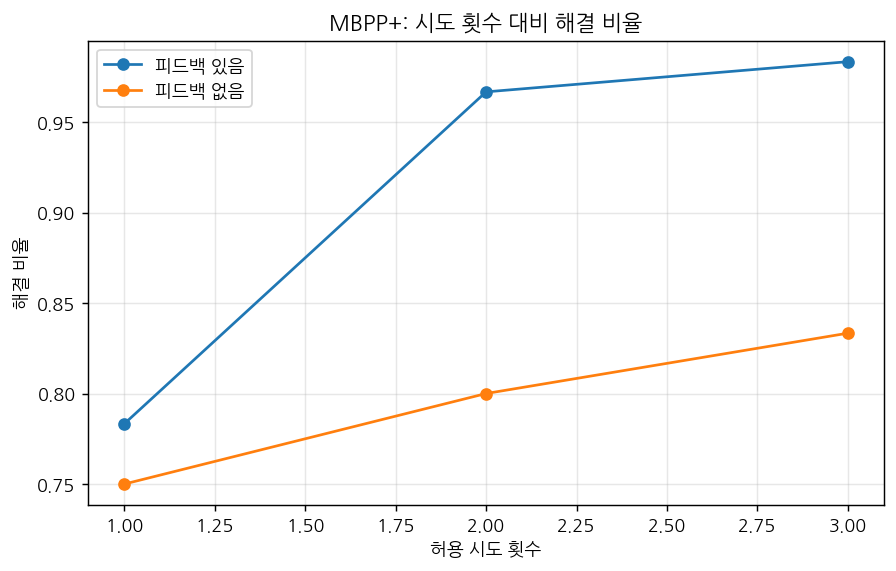

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/01_solved_by_attempt.png


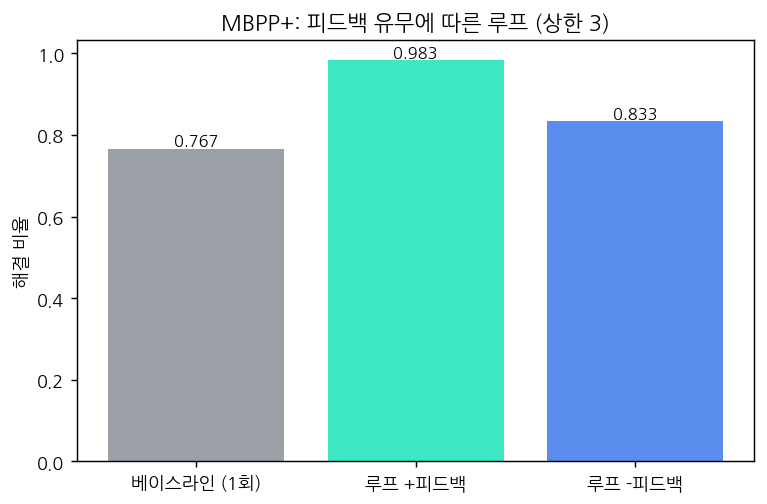

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/01_headline.png


PosixPath('/Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/01_headline.png')

In [6]:
final_fb = fb_curve[-1]
final_nofb = nofb_curve[-1]

show.head("핵심 비교")
d1 = show.compare("피드백 있는 루프 vs 베이스라인", base_pass, final_fb)
d2 = show.compare("피드백 없는 루프 vs 베이스라인", base_pass, final_nofb)

# 선 그래프가 막대보다 중요하다. 두 곡선이 같은 점에서 출발해 갈라지는
# 모양 자체가 "차이는 루프가 아니라 신호에서 왔다" 는 주장의 증거다.
plotting.line(
    "01_solved_by_attempt",
    x=list(range(1, MAX_ATTEMPTS + 1)),
    series={"피드백 있음": fb_curve, "피드백 없음": nofb_curve},
    xlabel="허용 시도 횟수",
    ylabel="해결 비율",
    title="MBPP+: 시도 횟수 대비 해결 비율",
)
plotting.ab_bar(
    "01_headline",
    labels=["베이스라인 (1회)", "루프 +피드백", "루프 -피드백"],
    values=[base_pass, final_fb, final_nofb],
    ylabel="해결 비율",
    title=f"MBPP+: 피드백 유무에 따른 루프 (상한 {MAX_ATTEMPTS})",
)

## C단계: 시도 상한이 막아 주는 실패 양식

시도 상한이 없으면, 문제를 풀지 못하는 루프는 **영원히 재시도하며 토큰을 태운다.** 이것이 **무한 수정 루프(infinite fix loop)** 실패 양식이다.

루프가 풀지 못한 문제를 하나 골라 시도를 여러 번 허용하고, 누적 토큰 비용을 출력한다. **요점은 "시도를 더 하는 것이 절대 도움이 안 된다" 가 아니라, 비용은 자라는데 수렴은 보장되지 않는다는 것**이다. 그래서 딱딱한 상한과 에스컬레이션이 가드레일이 된다.


In [7]:
show.head("무한 수정 루프 시연")

# 피드백 루프가 3회 안에 못 푼 문제들. 이 중 하나로 상한을 풀어 본다.
unsolved = [problems[i] for i, r in enumerate(fb_runs) if not r["solved"]]

if unsolved:
    target = unsolved[0]
    show.kv("대상", target.id)

    UNCAPPED = 6      # 상한을 3에서 6으로 올린다. '상한 없음' 의 축소 시연이다.
    # temperature=0.2 로 약간 올린 이유: 완전 결정적이면 같은 답만 6번 나온다.
    # 재샘플링에 최대한 유리한 조건을 주고도 실패한다는 것을 보이기 위해서다.
    with llm.track("uncapped") as u_unc:
        r = loops.self_refine(llm, target, max_attempts=UNCAPPED,
                              temperature=0.2, use_feedback=True)

    show.kv("소모한 시도", r["attempts"])
    show.kv("해결 여부", r["solved"])
    show.kv("태운 토큰", u_unc.total_tokens)

    # 비용은 시도에 선형이다. 수렴은 보장되지 않는다. 이 둘의 조합이 토큰 누수다.
    per_attempt = u_unc.total_tokens / max(1, r["attempts"])
    show.sub("계속 돌렸을 때의 비용 (시도에 선형, 수렴은 미보장)")
    proj = {f"{k}회 시도": int(per_attempt * k) for k in (3, 6, 12, 24)}
    show.show_dict(proj, "")

    show.bullet("시도마다 비용은 오르지만 수렴은 보장되지 않는다 (S2 '무한 수정 루프').")
    show.bullet("가드레일: 딱딱한 상한(보통 3회) 후 전체 컨텍스트와 함께 에스컬레이션.")
else:
    UNCAPPED = MAX_ATTEMPTS
    show.bullet("이번 실행에서는 모든 문제가 상한 안에 풀렸다. 시연할 미해결 사례가 없다.")


=========================================== 무한 수정 루프 시연 ============================================
  대상:                        mbppplus/769
  소모한 시도:                    6
  해결 여부:                     False
  태운 토큰:                     4556

---------------------------------- 계속 돌렸을 때의 비용 (시도에 선형, 수렴은 미보장) ----------------------------------
{
  "3\ud68c \uc2dc\ub3c4": 2278,
  "6\ud68c \uc2dc\ub3c4": 4556,
  "12\ud68c \uc2dc\ub3c4": 9112,
  "24\ud68c \uc2dc\ub3c4": 18224
}
  - 시도마다 비용은 오르지만 수렴은 보장되지 않는다 (S2 '무한 수정 루프').
  - 가드레일: 딱딱한 상한(보통 3회) 후 전체 컨텍스트와 함께 에스컬레이션.


## 결과 저장


In [8]:
metrics = {
    "notebook": "01_loop",
    "benchmark": "MBPP+ (EvalPlus)",
    "provider": llm.provider,        # 한국어판 추가: 어느 백엔드의 수치인지 기록
    "model": llm.model,
    "n_problems": len(problems),
    "max_attempts": MAX_ATTEMPTS,
    "baseline_pass_at_1": base_pass,
    "loop_with_feedback_curve": fb_curve,      # 곡선 전체를 저장해야 08번이 재분석할 수 있다
    "loop_without_feedback_curve": nofb_curve,
    "final_with_feedback": final_fb,
    "final_without_feedback": final_nofb,
    "delta_with_feedback": d1,
    "delta_without_feedback": d2,
    "tokens": {"baseline": u_base.total_tokens,
               "with_feedback": u_fb.total_tokens,
               "without_feedback": u_nofb.total_tokens},
}
runlog.save_metrics("01_loop", metrics)

runlog.log_run(
    pattern="loop-self-refine",
    duration_s=0,
    items_found=len(problems),
    actions_taken=int(final_fb * len(problems)),
    # 미해결 문제 수를 에스컬레이션으로 센다. 상한에 걸린 것은 사람에게 넘어가야 할 몫이다.
    escalations=len([r for r in fb_runs if not r["solved"]]),
    tokens_estimate=u_base.total_tokens + u_fb.total_tokens + u_nofb.total_tokens,
    outcome="fix-proposed",
)

  saved metrics -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/01_loop.json
  logged run -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/loop-run-log.json (loop-self-refine: fix-proposed, ~106312 tokens)


{'run_id': '2026-08-19T05:24:09Z',
 'pattern': 'loop-self-refine',
 'duration_s': 0.0,
 'items_found': 60,
 'actions_taken': 59,
 'escalations': 1,
 'tokens_estimate': 106312,
 'outcome': 'fix-proposed'}

## 이 실행이 실제로 보여 준 것 (위 수치에서 계산)


In [9]:
show.head("이 실행이 실제로 보여 준 것")

fb_gain = final_fb - base_pass
nofb_gain = final_nofb - base_pass

print(f"탐욕적 시도 1회는 MBPP+ 문제의 {base_pass:.0%} 를 풀었다.")
print(f"실행 피드백이 있는 루프는 {MAX_ATTEMPTS}회 이내에 {final_fb:.0%} 에 도달했다 (베이스라인 대비 {fb_gain:+.1%}).")
print(f"피드백이 없는 루프는 {final_nofb:.0%} 에 도달했다 (베이스라인 대비 {nofb_gain:+.1%}).")
print()

# ⚠️ 함정: 결론을 하드코딩하지 않고 실제 수치에서 분기시킨다. 다른 모델이나
#    다른 표본에서 결과가 뒤집히면 이 셀은 그 사실을 그대로 말해야 한다.
#    "이 노트북은 X를 증명한다" 고 미리 써 두면 그것은 측정이 아니라 주장이다.
if fb_gain > nofb_gain + 1e-9 and fb_gain > 0:
    print("=> 루프를 작동하게 만든 것은 실행 피드백이었다. 피드백 있는 루프가 단일 시도와")
    print("   피드백 없는 루프를 모두 이겼다. 그 격차가 실제 코드에서 재현된 Huang 의 결과다.")
    print("   혼잣말만 하는 루프는 거의 나아지지 않고, 검증 가능한 테스트 신호에 연결된")
    print("   루프는 나아진다.")
elif fb_gain <= 0:
    print("=> 이 부분집합에서는 루프가 1회 시도를 이기지 못했다. 실패한 문제들이 실패 케이스를")
    print("   보여 줘도 모델의 능력 밖이었다는 뜻이다(강한 포화). 정직한 교훈은 그대로다.")
    print("   완료까지 반복은 피드백이 주어졌을 때 모델이 해낼 수 있는 곳에서만 도움이 된다.")
else:
    print("=> 피드백이 도움이 됐고, 피드백 없는 루프와의 격차가 신호가 중요했음을 보여 준다.")
print()

print(f"토큰 비용: 베이스라인 {u_base.total_tokens}, +피드백 {u_fb.total_tokens}, -피드백 {u_nofb.total_tokens}.")
print("루프는 1회 시도보다 몇 배의 토큰을 쓴다. 시도 상한과 에스컬레이션(무한 수정 가드레일)이")
print("선택 사항이 아니라 필수인 이유가 이것이다.")


========================================= 이 실행이 실제로 보여 준 것 =========================================
탐욕적 시도 1회는 MBPP+ 문제의 77% 를 풀었다.
실행 피드백이 있는 루프는 3회 이내에 98% 에 도달했다 (베이스라인 대비 +21.7%).
피드백이 없는 루프는 83% 에 도달했다 (베이스라인 대비 +6.7%).

=> 루프를 작동하게 만든 것은 실행 피드백이었다. 피드백 있는 루프가 단일 시도와
   피드백 없는 루프를 모두 이겼다. 그 격차가 실제 코드에서 재현된 Huang 의 결과다.
   혼잣말만 하는 루프는 거의 나아지지 않고, 검증 가능한 테스트 신호에 연결된
   루프는 나아진다.

토큰 비용: 베이스라인 22446, +피드백 35069, -피드백 48797.
루프는 1회 시도보다 몇 배의 토큰을 쓴다. 시도 상한과 에스컬레이션(무한 수정 가드레일)이
선택 사항이 아니라 필수인 이유가 이것이다.
